Training set bias:
  Aligned:   91.30%
  Conflict:  8.70%


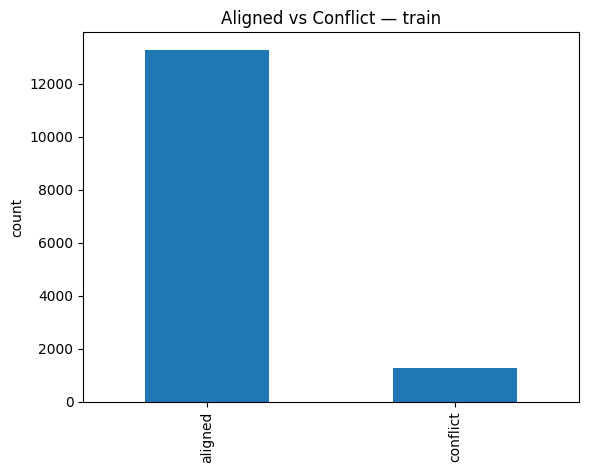

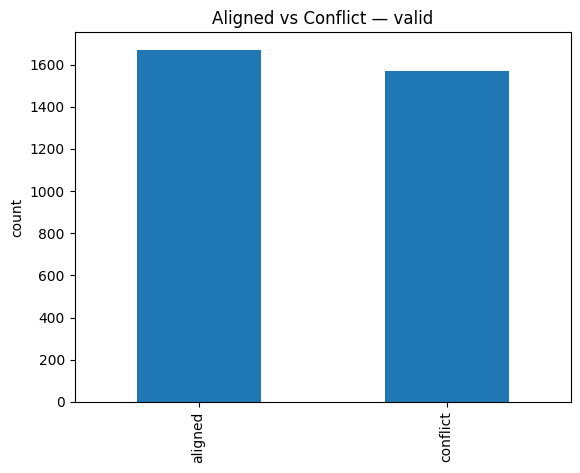

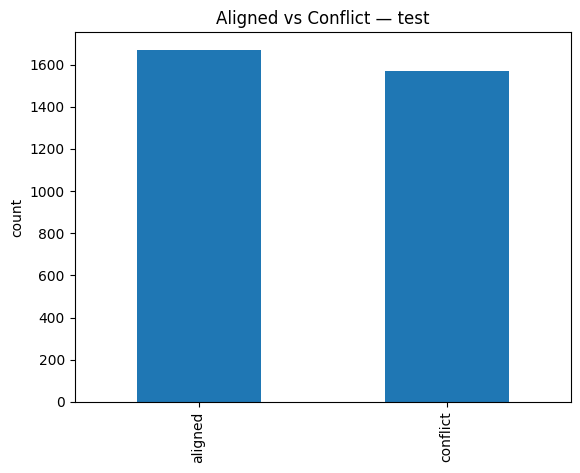

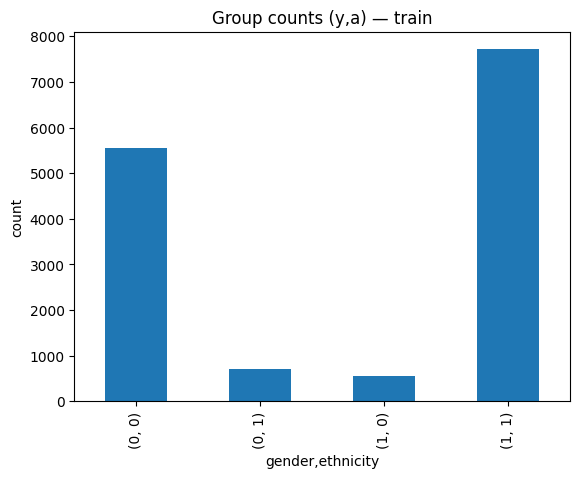

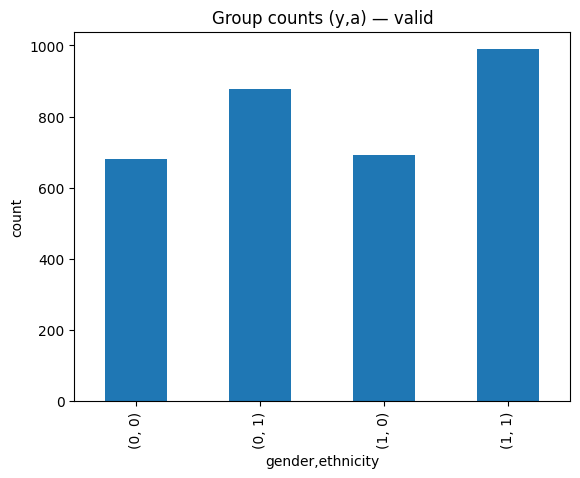

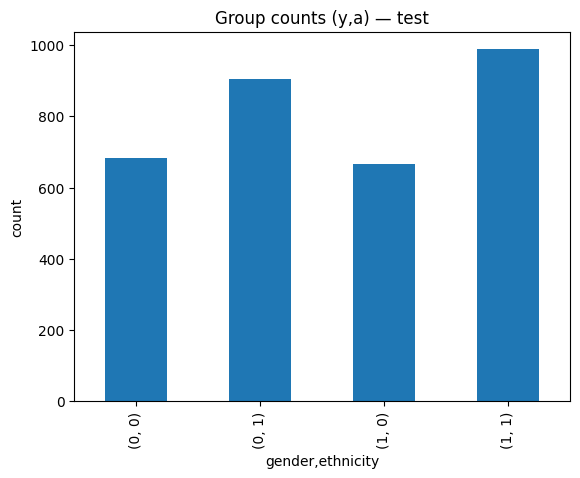

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

ROOT = "/home/ulkar/debias-medimg/data/fairface"
META = "metadata.csv"

# Load metadata
df_all = pd.read_csv(f"{ROOT}/{META}")

# Split mapping
SPLITS = {0: "train", 1: "valid", 2: "test"}

# -------------------------------
# Compute majority (gender, ethnicity) groups FROM TRAIN ONLY
# -------------------------------
train_df = df_all[df_all["split"] == 0]


group_freq = (
    train_df
    .groupby(["gender", "ethnicity"])
    .size()
    .reset_index(name="count")
)

# mark majority ethnicity per gender
group_freq["is_majority"] = (
    group_freq
    .groupby("gender")["count"]
    .transform(lambda x: x == x.max())
)

majority_map = {
    (row.gender, row.ethnicity): row.is_majority
    for _, row in group_freq.iterrows()
}

def is_aligned(row):
    return majority_map.get((row.gender, row.ethnicity), False)

# apply alignment to ALL splits
df_all["aligned"] = df_all.apply(is_aligned, axis=1)
# -------------------------------
# Training-set bias strength
# -------------------------------
train_df = df_all[df_all["split"] == 0]

n_total = len(train_df)
n_conflict = (~train_df["aligned"]).sum()

conflict_pct = 100 * n_conflict / n_total
aligned_pct = 100 - conflict_pct

print(f"Training set bias:")
print(f"  Aligned:   {aligned_pct:.2f}%")
print(f"  Conflict:  {conflict_pct:.2f}%")

# -------------------------------
# Summary per split
# -------------------------------
rows = []
dfs = {}

for split_id, split_name in SPLITS.items():
    df = df_all[df_all["split"] == split_id]
    dfs[split_name] = df

    total = len(df)
    n_align = int(df["aligned"].sum())
    n_conf = total - n_align

    y_counts = df["gender"].value_counts().reindex([0, 1], fill_value=0)
    a_counts = df["ethnicity"].value_counts().reindex([0, 1], fill_value=0)

    rows.append({
        "split": split_name,
        "total": total,
        "aligned": n_align,
        "conflict": n_conf,
        "aligned_%": round(100 * n_align / total, 2) if total else 0.0,
        "conflict_%": round(100 * n_conf / total, 2) if total else 0.0,
        "y=0": int(y_counts[0]),
        "y=1": int(y_counts[1]),
        "a=0": int(a_counts[0]),
        "a=1": int(a_counts[1]),
    })

summary_df = pd.DataFrame(rows).set_index("split")
summary_df

# Aligned vs Conflict per split
for split in ["train", "valid", "test"]:
    s = summary_df.loc[split, ["aligned", "conflict"]]
    ax = s.plot(kind="bar")
    ax.set_title(f"Aligned vs Conflict — {split}")
    ax.set_ylabel("count")
    plt.show()

# Group counts (y, a) per split
for split, df in dfs.items():
    gc = df.groupby(["gender", "ethnicity"]).size().unstack("ethnicity", fill_value=0)
    ax = gc.stack().plot(kind="bar")
    ax.set_title(f"Group counts (y,a) — {split}")
    ax.set_ylabel("count")
    plt.show()



In [8]:
import os
import pandas as pd

ROOT = "/home/ulkar/debias-medimg/data/fairface"
META = "metadata.csv"
SPLIT_MAP = {0: "train", 1: "valid", 2: "test"}

# Read all rows once from metadata.csv
df_all = pd.read_csv(os.path.join(ROOT, META)).copy()

rows = []
for split_id, split_name in SPLIT_MAP.items():
    df = df_all[df_all["split"] == split_id]
    gc = df.groupby(["gender", "ethnicity"]).size().unstack("ethnicity", fill_value=0)

    # Ensure all four (gender, ethnicity) groups exist
    gc = gc.reindex(index=[0, 1], columns=[0, 1], fill_value=0)

    rows.append(
        {
            "split": split_name,
            "y0_a0": int(gc.loc[0, 0]),
            "y0_a1": int(gc.loc[0, 1]),
            "y1_a0": int(gc.loc[1, 0]),
            "y1_a1": int(gc.loc[1, 1]),
            "total": int(gc.values.sum()),
        }
    )

out_df = pd.DataFrame(rows).set_index("split").reindex(["train", "valid", "test"])
out_df

# Write CSV and LaTeX for paper use
out_dir = "/home/ulkar/debias-medimg/data/fairface"
os.makedirs(out_dir, exist_ok=True)
csv_path = os.path.join(out_dir, "group_counts_table.csv")
tex_path = os.path.join(out_dir, "group_counts_table.tex")
out_df.to_csv(csv_path)



print("Wrote CSV to", csv_path)

Wrote CSV to /home/ulkar/debias-medimg/data/fairface/group_counts_table.csv
